# Training Analysis Notebook

This notebook analyzes the trained models on a classification task ordinary vs accidental.

## Contents

- Loading and parsing training statistics
- Training curves
- Model evaluation on test set
- Sample results

In [55]:
# Import libraries
import sys
sys.path.append('..')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from torch.utils.data import DataLoader
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from src.model import build_model
from src.data_pipeline import ImagePathDataset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [52]:
# Function to parse stats txt file
def parse_stats_file(filepath):
    epochs = []
    train_loss = []
    train_acc = []
    train_f1 = []
    val_loss = []
    val_acc = []
    val_f1 = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Match epoch summary lines
            epoch_match = re.search(r'Epoch (\d+)/\d+ - [\d.]+s', line)
            if epoch_match:
                epoch = int(epoch_match.group(1))
                epochs.append(epoch)
            
            train_match = re.search(r'train loss: ([\d.]+) acc: ([\d.]+) f1: ([\d.]+)', line)
            if train_match:
                train_loss.append(float(train_match.group(1)))
                train_acc.append(float(train_match.group(2)))
                train_f1.append(float(train_match.group(3)))
            
            val_match = re.search(r'val   loss: ([\d.]+) acc: ([\d.]+) f1: ([\d.]+)', line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                val_acc.append(float(val_match.group(2)))
                val_f1.append(float(val_match.group(3)))
    
    return {
        'epochs': epochs,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'train_f1': train_f1,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    }

# Load stats for both experiments
outputs_dir = '../outputs/models'
experiments = {}
for filename in os.listdir(outputs_dir):
    if filename.endswith('_stats.txt') and "resnet_none" in filename:
        exp_name = filename.replace('_stats.txt', '')
        filepath = os.path.join(outputs_dir, filename)
        experiments[exp_name] = parse_stats_file(filepath)

print("Loaded experiments:", list(experiments.keys()))

Loaded experiments: ['resnet_none']


### Training performance

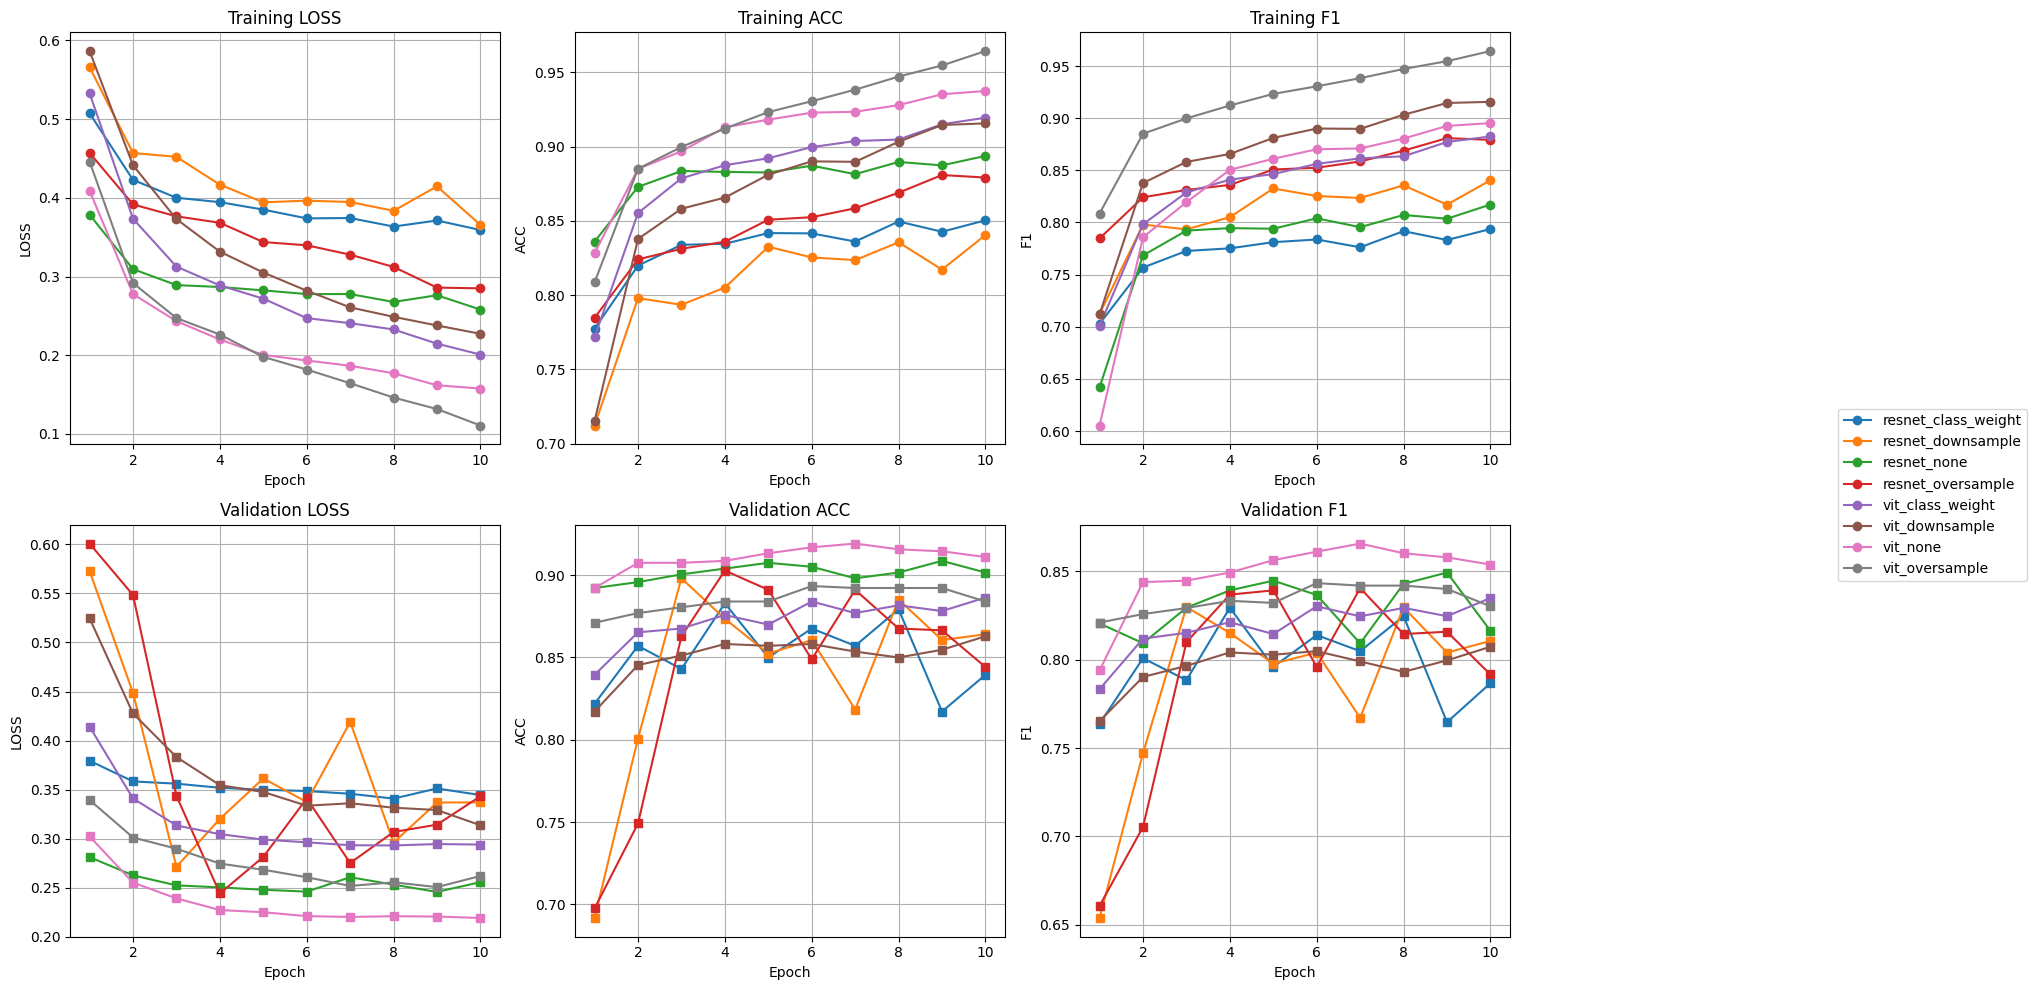

In [47]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['loss', 'acc', 'f1']

# Store handles/labels once for global legend
handles = []
labels = []

for i, metric in enumerate(metrics):
    ax_train = axes[0, i]
    ax_val = axes[1, i]
    
    for exp_name, data in experiments.items():
        epochs = data['epochs']
        train_vals = data[f'train_{metric}']
        val_vals = data[f'val_{metric}']
        
        train_line, = ax_train.plot(
            epochs, train_vals, label=exp_name, marker='o'
        )
        ax_val.plot(
            epochs, val_vals, label=exp_name, marker='s'
        )
        
        if i == 0:
            handles.append(train_line)
            labels.append(exp_name)
    
    ax_train.set_title(f'Training {metric.upper()}')
    ax_train.set_xlabel('Epoch')
    ax_train.set_ylabel(metric.upper())
    ax_train.grid(True)
    
    ax_val.set_title(f'Validation {metric.upper()}')
    ax_val.set_xlabel('Epoch')
    ax_val.set_ylabel(metric.upper())
    ax_val.grid(True)

fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10
)

# Leave space on right for legend
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

The data shows that Vision Transformers (ViT) generally outperform ResNet across all metrics. Models trained with oversampling tend to achieve the highest performance scores, while models using downsampling are consistently the most unstable and least effective. The ViT models show a much higher capacity to learn the training data (reaching near-perfect scores) but exhibit a notable gap between training and validation performance, indicating some degree of overfitting.

#### ResNet Performance

* **Best Variant: resnet_none (Standard)**
While `resnet_oversample` reaches slightly higher peak F1 scores at certain points, the standard `resnet_none` model is the most stable. it maintains a consistent upward trend in accuracy and F1 score with the least amount of "jitter" in the validation loss.
* **Worst Variant: resnet_downsample**
This is clearly the worst-performing ResNet model. Its validation metrics are extremely volatile, with sharp drops in accuracy and huge spikes in loss. This suggests that removing data to balance the classes deprived the model of the features it needed to generalize properly.

#### ViT (Vision Transformer) Performance

* **Best Variant: vit_oversample**
This model achieved the highest overall training and validation F1 scores. By replicating minority class samples, the Transformer was able to learn the nuances of the dataset more effectively than any other configuration. (Note: `vit_none` is a close runner-up as it achieved the lowest overall validation loss).
* **Worst Variant: vit_downsample**
Similar to the ResNet architecture, the downsampling strategy performed the poorest for ViT. It resulted in the lowest validation accuracy and F1 scores among the Transformer group, confirming that reducing the dataset size is detrimental to these high-capacity models.


#### Summary

The most reliable and high-performing model is **vit_oversample**. A more lightweight or stable alternative is **resnet_none** among the traditional architectures. **Downsampling** in both cases significantly degrades performance and stability.

### Test data

In [ ]:
test_csv = '../outputs/splits/test_records.csv'
test_df = pd.read_csv(test_csv)

unique_labels = sorted(test_df["label"].unique())
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {v: k for k, v in label_to_index.items()}   # Good to verify

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

test_records = [{'path': '../' + row['path'], 'label': row['label']} for _, row in test_df.iterrows()]
test_dataset = ImagePathDataset(test_records, label_to_index, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print("Label mapping used:", label_to_index, len(test_dataset))

Label mapping used: {'accidental': 0, 'ordinary': 1} 853


### Evaluation and Confusion Matrix

Final Comparison:
             val_loss  val_acc  val_f1  test_acc   test_f1  test_precision  \
resnet_none    0.2556   0.9015  0.8163  0.888628  0.932191        0.914566   

             test_recall  test_roc_auc  
resnet_none     0.950509       0.91518  

Confusion Matrices:


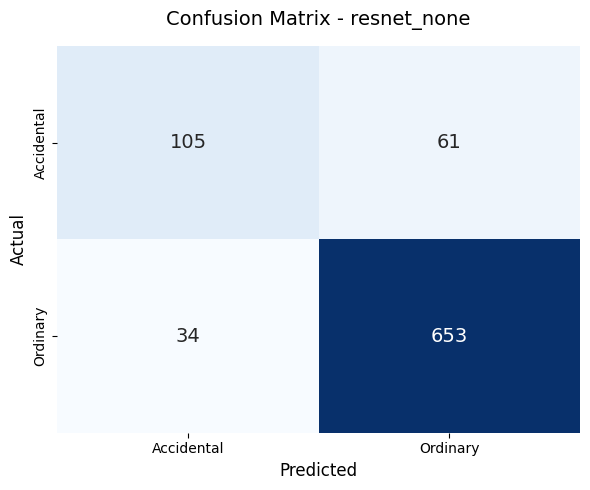

In [57]:
# Function to evaluate model on test set
def evaluate_model(model_path, test_loader, device):
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['config']

    selected_labels = (
        config.get('experiment', {}).get('selected_labels')
        or config.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    # Build model
    model = build_model(config, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            # Convert logits to probabilities
            probs = F.softmax(outputs, dim=1)

            preds = outputs.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # probability of positive class
    
    # Metrics
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='binary')
    precision = precision_score(all_targets, all_preds, average='binary')
    recall = recall_score(all_targets, all_preds, average='binary')
    roc_auc = roc_auc_score(all_targets, all_probs)
    cm = confusion_matrix(all_targets, all_preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }


# Evaluate both models
test_results = {}
for exp_name in experiments.keys():
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if os.path.exists(model_path):
        test_results[exp_name] = evaluate_model(model_path, test_loader, device)
    else:
        print(f"Model file not found: {model_path}")


# Compare final validation metrics
final_metrics = {}
for exp_name, data in experiments.items():
    final_metrics[exp_name] = {
        'val_loss': data['val_loss'][-1],
        'val_acc': data['val_acc'][-1],
        'val_f1': data['val_f1'][-1],
        'test_acc': test_results.get(exp_name, {}).get('accuracy', None),
        'test_f1': test_results.get(exp_name, {}).get('f1', None),
        'test_precision': test_results.get(exp_name, {}).get('precision', None),
        'test_recall': test_results.get(exp_name, {}).get('recall', None),
        'test_roc_auc': test_results.get(exp_name, {}).get('roc_auc', None),
    }

comparison_df = pd.DataFrame.from_dict(final_metrics, orient='index')
print("Final Comparison:")
print(comparison_df)


def plot_confusion_matrix(cm, exp_name, labels=['Ordinary', 'Accidental'], save_path=None):
    """
    Plot and optionally save a confusion matrix heatmap using seaborn.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={'size': 14},
        cbar=False
    )
    plt.title(f'Confusion Matrix - {exp_name}', fontsize=14, pad=15)
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    plt.close()


# Print confusion matrices separately
print("\nConfusion Matrices:")
for exp_name, metrics in test_results.items():    
    # Plot with seaborn
    plot_confusion_matrix(
        metrics['confusion_matrix'], 
        exp_name, 
        labels=['Accidental', 'Ordinary'])

### Sample images analysis

,index,path,true_label,resnet_class_weight,resnet_downsample,resnet_none,resnet_oversample
0,0,../data\raw\reddit_data\953ce3b2c8ace4d2.jpg,accidental,accidental,accidental,accidental,accidental
1,1,../data\raw\coco_data\3277.jpg,ordinary,accidental,accidental,accidental,accidental
2,2,../data\raw\coco_data\111.jpg,ordinary,ordinary,ordinary,ordinary,ordinary
3,3,../data\raw\coco_data\1634.jpg,ordinary,ordinary,ordinary,ordinary,ordinary
4,4,../data\raw\reddit_data\a9e75d3c294914b5.jpg,accidental,accidental,accidental,accidental,accidental


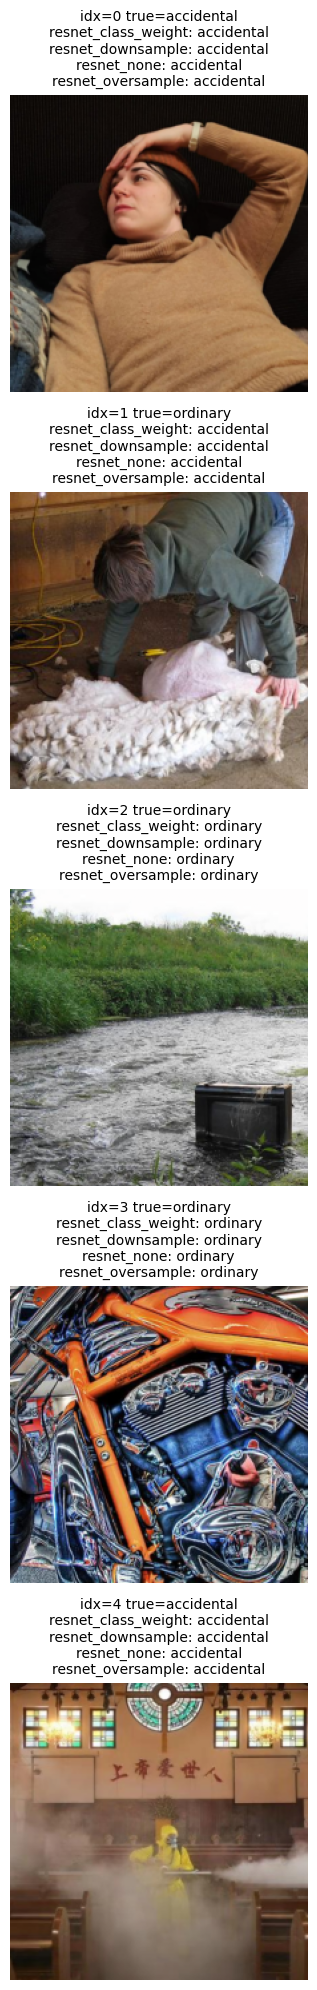

In [ ]:
# Sample some test examples and compare model predictions
sample_indices = [0, 1, 2, 3, 4]
sample_records = [test_records[i] for i in sample_indices]

images = []
targets = []
for rec in sample_records:
    img = Image.open(rec['path']).convert('RGB')
    images.append(transform(img))
    targets.append(label_to_index[rec['label']])

images = torch.stack(images).to(device)
targets = torch.tensor(targets)

model_preds = {}
for exp_name in experiments.keys():
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if not os.path.exists(model_path):
        continue

    checkpoint = torch.load(model_path, map_location=device)
    cfg = checkpoint['config']
    selected_labels = (
        cfg.get('experiment', {}).get('selected_labels')
        or cfg.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    model = build_model(cfg, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().tolist()

    model_preds[exp_name] = preds

rows = []
for i, rec in enumerate(sample_records):
    row = {
        'index': sample_indices[i],
        'path': rec['path'],
        'true_label': rec['label']
    }
    for exp_name, preds in model_preds.items():
        row[exp_name] = index_to_label[preds[i]]
    rows.append(row)

sample_df = pd.DataFrame(rows)
# Sample some test examples and compare model predictions
sample_indices = [0, 1, 2, 3, 4]

batch_images, batch_targets = next(iter(test_loader))
sample_images = batch_images[sample_indices].to(device)

model_preds = {}
for exp_name in experiments:
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if not os.path.exists(model_path):
        continue

    checkpoint = torch.load(model_path, map_location=device)
    cfg = checkpoint['config']
    selected_labels = (
        cfg.get('experiment', {}).get('selected_labels')
        or cfg.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    model = build_model(cfg, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()

    with torch.no_grad():
        outputs = model(sample_images)
        model_preds[exp_name] = outputs.argmax(dim=1).cpu().tolist()

rows = []
for pos, idx in enumerate(sample_indices):
    row = {
        'index': idx,
        'path': test_records[idx]['path'],
        'true_label': test_records[idx]['label']
    }
    for exp_name, preds in model_preds.items():
        row[exp_name] = index_to_label[preds[pos]]
    rows.append(row)

sample_df = pd.DataFrame(rows)

inv_norm = transforms.Normalize(
    mean=[-m / s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1 / s for s in [0.229, 0.224, 0.225]]
)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(10, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for pos, idx in enumerate(sample_indices):
    img = inv_norm(sample_images[pos].cpu()).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()

    ax = axes[pos]
    ax.imshow(img)
    ax.axis('off')

    pred_lines = "\n".join(
        f"{exp}: {index_to_label[model_preds[exp][pos]]}"
        for exp in model_preds
    )
    ax.set_title(
        f"idx={idx} true={test_records[idx]['label']}\n{pred_lines}",
        fontsize=10
    )

plt.tight_layout()
sample_df